In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import platform

if platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")  # Windows 내장
elif platform.system() == "Darwin":
    plt.rc("font", family="AppleGothic")  # macOS
else:
    plt.rc("font", family="NanumGothic")  # Ubuntu: sudo apt install fonts-nanum

plt.rc("axes", unicode_minus=False)

In [50]:
TITANIC_URL = (
    "https://raw.githubusercontent.com/" "datasciencedojo/datasets/master/titanic.csv"
)
titanic = pd.read_csv(TITANIC_URL)
titanic.shape

(891, 12)

## BASIC

### ── 타이타닉 matplotlib ─────────────────────────

#### B1. 나이 히스토그램 (bins=25, 제목·축 레이블 포함)

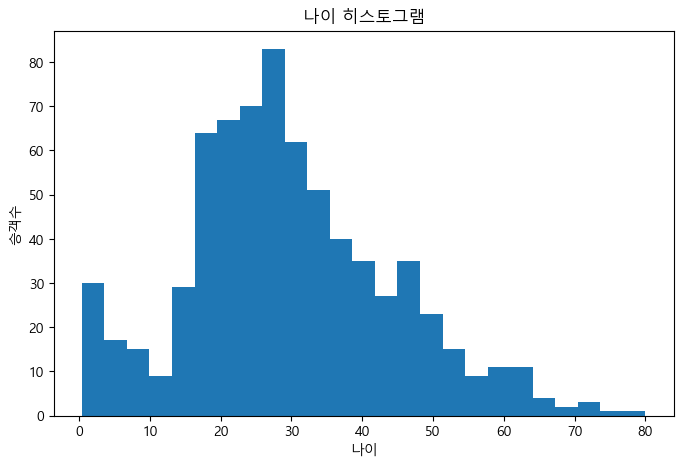

In [51]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(titanic["Age"], bins=25)
ax.set_xlabel("나이")
ax.set_ylabel("승객수")
ax.set_title("나이 히스토그램")
plt.savefig("hist.png", dpi=150, bbox_inches="tight")
plt.show()

#### B2. 성별 생존자 수 막대그래프

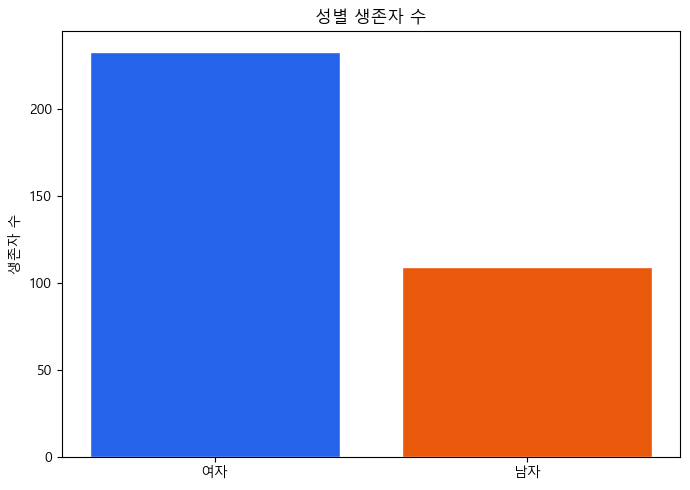

In [52]:
surv_class = titanic.groupby("Sex")["Survived"].sum()

labels = ["여자", "남자"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(
    labels,
    surv_class.values,
    color=["#2563eb", "#ea580c"],
    edgecolor="white",
)

ax.set_title("성별 생존자 수")
ax.set_ylabel("생존자 수")
plt.tight_layout()
plt.savefig("bar.png", dpi=150, bbox_inches="tight")
plt.show()

#### B3. 나이 vs 요금 산점도 (생존여부 색상 구분)

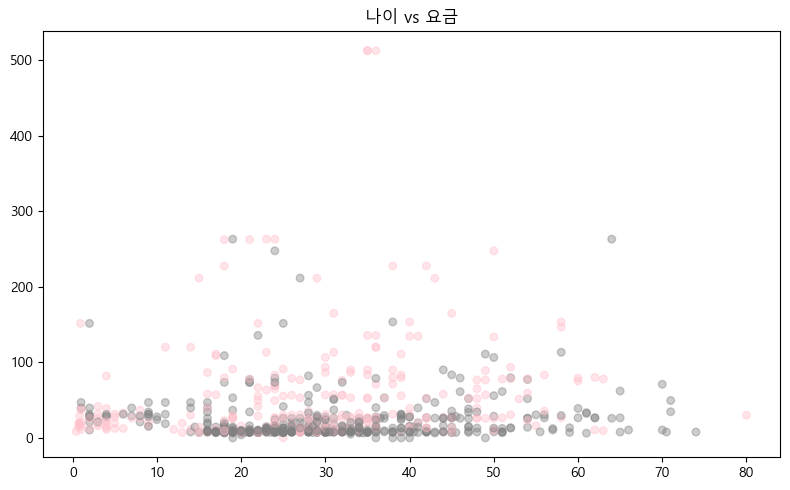

In [53]:
colors = titanic["Survived"].map({0: "gray", 1: "pink"})

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(titanic["Age"], titanic["Fare"], c=colors, alpha=0.4, s=30)
ax.set_title("나이 vs 요금")
plt.tight_layout()
plt.savefig("scatter.png", dpi=150, bbox_inches="tight")
plt.show()

#### B4. 등급별 요금 박스플롯

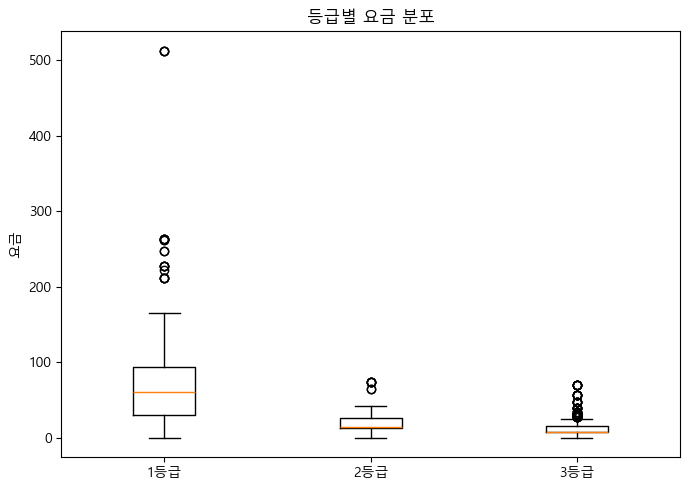

In [54]:
data = [titanic[titanic["Pclass"] == c]["Fare"].dropna() for c in [1, 2, 3]]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(data, tick_labels=["1등급", "2등급", "3등급"])
ax.set_ylabel("요금")
ax.set_title("등급별 요금 분포")
plt.tight_layout()
plt.savefig("boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

#### B5. 탑승항(Embarked)별 승객 비율 파이차트

In [55]:
titanic['Embarked'].isnull().sum()

np.int64(2)

In [56]:
titanic['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

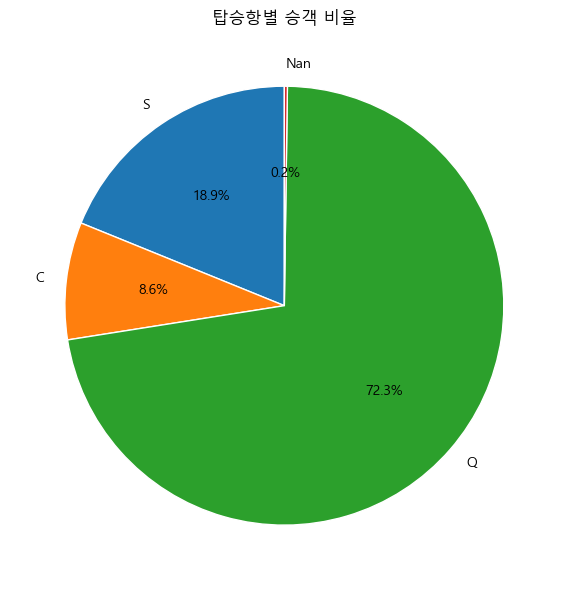

In [57]:
class_counts = titanic["Embarked"].value_counts(dropna=False).sort_index()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    class_counts.values,
    labels=["S", "C", "Q", "Nan"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white"),
)
ax.set_title("탑승항별 승객 비율")
plt.tight_layout()
plt.savefig("pie.png", dpi=150, bbox_inches="tight")
plt.show()


### ── IMDB plotly ──────────────────────────────────

#### B6. IMDB_Rating 히스토그램 (marginal='box' 포함)

In [59]:
imdb = pd.read_csv('./imdb_top_1000.csv')
imdb.shape

(1000, 16)

In [61]:
imdb['IMDB_Rating'].value_counts()

IMDB_Rating
7.7    157
7.8    151
8.0    141
8.1    127
7.6    123
7.9    106
8.2     67
8.3     44
8.4     31
8.5     20
8.6     15
8.8      5
8.7      5
9.0      3
8.9      3
9.3      1
9.2      1
Name: count, dtype: int64

In [64]:
fig = px.histogram(
    imdb,
    x="IMDB_Rating",
    nbins=15,
    marginal="box",
    title="IMDB_Rating 히스토그램",
    template="ggplot2",
)
fig.show()

#### B7. 투표 수 vs 평점 scatter (hover_name=영화 제목)

In [65]:
imdb.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='str')

In [ ]:
fig = px.scatter(
    imdb,
    x="No_of_Votes",
    y="IMDB_Rating",
    hover_name="Series_Title",
    title="투표 수 VS 평점",
    template="gridon",
    opacity=0.5,
    labels={"No_of_Votes": "투표 수", "IMDB_Rating": "평점"},
)

fig.show()


#### B8. B7 차트를 HTML로 저장

In [70]:
fig.write_html("scatter(imdb).html")

---

## APPLIED

In [73]:
sa = pd.read_csv("./seoul_apartment.csv")
sa.shape

(1260226, 13)

```text

# A2. 월별 거래 건수 막대그래프 (HTML 저장)
# A3. 구별 평균 거래가격 수평 막대그래프
#     힌트: sa['구'] = sa['시군구'].str.split().str[1]

#### A1. 월별 평균 거래가격 꺾은선그래프 (HTML 저장)

In [75]:
sa.columns

Index(['NO', '시군구', '번지', '본번', '부번', '단지명', '전용면적(㎡)', '계약년월', '계약일',
       '거래금액(만원)', '층', '건축년도', '도로명'],
      dtype='str')

In [76]:
sa.info()

<class 'pandas.DataFrame'>
RangeIndex: 1260226 entries, 0 to 1260225
Data columns (total 13 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   NO        1260226 non-null  int64  
 1   시군구       1260226 non-null  str    
 2   번지        1260226 non-null  str    
 3   본번        1260226 non-null  int64  
 4   부번        1260226 non-null  int64  
 5   단지명       1260226 non-null  str    
 6   전용면적(㎡)   1260226 non-null  float64
 7   계약년월      1260226 non-null  int64  
 8   계약일       1260226 non-null  int64  
 9   거래금액(만원)  1260226 non-null  int64  
 10  층         1260226 non-null  int64  
 11  건축년도      1260226 non-null  int64  
 12  도로명       1260226 non-null  str    
dtypes: float64(1), int64(8), str(4)
memory usage: 125.0 MB


In [77]:
sa.head(1)

,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),층,건축년도,도로명
0,1,서울특별시 종로구 사직동,9,9,0,광화문스페이스본(101동~105동),94.51,200811,3,63000,6,2008,사직로8길 4


In [78]:
# 계약년월 문자열 변환
sa["계약년월"] = sa["계약년월"].astype(str)

In [80]:
monthly_avg = (
    sa.groupby("계약년월")["거래금액(만원)"].mean().reset_index()
)

fig = px.line(
    monthly_avg,
    x="계약년월",
    y="거래금액(만원)",
    title="월 별 평균 거래가격",
    markers=True,
    template="plotly_white",
    labels={"계약년월": "계약년월", "거래금액(만원)": "평균 거래가격(만원)"},
)

fig.show()
fig.write_html("monthly_avg.html")